# Text Normalization

## Definition
Text normalization is the process of transforming text into a canonical, standard form so that variations of the same word or phrase are treated consistently. It goes beyond basic cleaning to handle contractions, abbreviations, Unicode characters, slang, and informal language. The goal is to reduce vocabulary size while preserving meaning.

## Why It Is Needed
- **Vocabulary Reduction:** Words like `running`, `runs`, and `ran` can be mapped to a common base, reducing feature space.
- **Consistency:** Ensures `U.S.A`, `USA`, and `United States` are understood as the same entity.
- **Better Generalization:** Models trained on normalized text generalize better to unseen variations.

## Real-World Applications
- Normalizing product names in e-commerce search engines
- Standardizing medical terminology in health records
- Handling slang and abbreviations in social media analysis
- Expanding contractions in chatbot preprocessing pipelines
- Currency and number normalization in financial text processing

## Important Points
- **Lowercasing:** `Apple` → `apple` — most basic normalization step.
- **Contraction Expansion:** `don't` → `do not`, `I'm` → `I am`.
- **Unicode Normalization:** Converts accented or special characters to ASCII equivalents (e.g., `café` → `cafe`).
- **Number Normalization:** `10`, `ten`, `10.0` can be mapped to a single token.
- **Spell Correction:** Fixing typos like `helo` → `hello` to avoid out-of-vocabulary issues.

## Visual Understanding
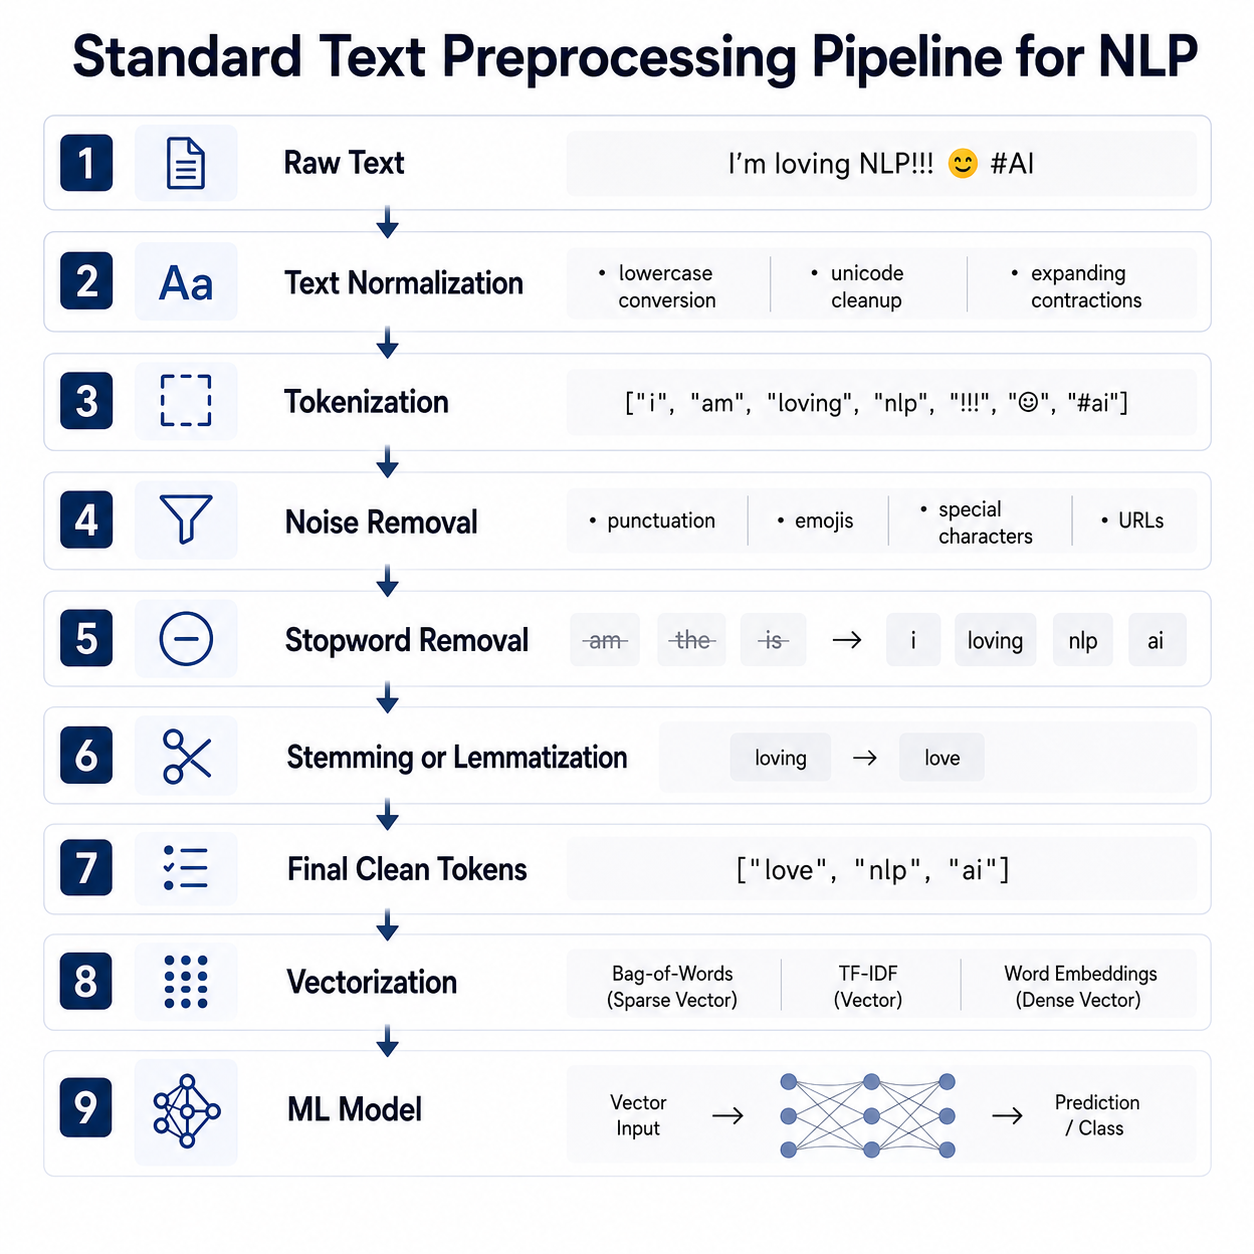

## Implementation
Practical implementation will be added here.

## Key Takeaways
- Normalization reduces vocabulary size and improves model efficiency.
- Contraction expansion is critical for sentiment and intent analysis.
- Unicode normalization prevents encoding-related errors in multilingual text.
- The extent of normalization depends on the downstream NLP task.
- Over-normalization can destroy meaningful distinctions — apply carefully.

In [ ]:
# special characters

In [1]:
import string

text = "hello world! let's code :#python #AI"

translator = str.maketrans('','' , string.punctuation)
cleaned_text = text.translate(translator)
print(cleaned_text)

hello world lets code python AI


In [2]:
# extra white spaces

In [3]:
text = "   hello    world.  "

cleaned_text = " ".join(text.split())
print(cleaned_text)

hello world.


In [5]:
!pip install contractions


   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ---------- ----------------------------- 1/4 [anyascii]
   ------------------------------ --------- 3/4 [contractions]
   ---------------------------------------- 4/4 [contractions]



In [8]:
import contractions

text = "don't , shouldn't , wouldn't , couldn't"

expanded_text = contractions.fix(text)
print(expanded_text)

do not , should not , would not , could not


In [9]:
# handle numbers 

text = " I have 2 apples and 3 oranges "

In [13]:
import re 
cleaned_text= re.sub(r'\d+', "", text)
print(cleaned_text)

 I have  apples and  oranges 


In [15]:
text = "I have 2 apples and 3 bananas"

num_to_digit = {
    "0": "zero",
    "1": "one",
    "2": "two",
    "3": "three",
    "4": "four",
    "5": "five",
    "6": "six",
    "7": "seven",
    "8": "eight",
    "9": "nine"
}

cleaned_text = ""

for char in text:
    if char.isdigit():
        cleaned_text += num_to_digit[char]
    else:
        cleaned_text += char

print(cleaned_text)

I have two apples and three bananas


In [16]:
import re

# Sample text with URLs, emails, hashtags
text = "Visit http://example.com for more info. Contact us at contact@example.com #AI"

# Replace URLs and emails with placeholders
processed_text = re.sub(r'http\S+|www\S+|https\S+', 'URL', text)  # URL
processed_text = re.sub(r'\S+@\S+', 'EMAIL', processed_text)  # Email

# Replace hashtags with 'HASHTAG' followed by the content
processed_text = re.sub(r'#(\S+)', r'HASHTAG \1', processed_text)  # Keep word after #

print(processed_text)

Visit URL for more info. Contact us at EMAIL HASHTAG AI


In [17]:
!pip install pyspellchecker

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------------------ --------- 5.5/7.2 MB 41.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 31.8 MB/s  0:00:00


In [18]:
from spellchecker import SpellChecker

# Sample text with spelling mistakes
text = "I recieved a messsage."

# Correct spelling
spell = SpellChecker()
words = text.split()
corrected_text = " ".join([spell.correction(word) for word in words])
print(corrected_text)

I received a message
